<a href="https://colab.research.google.com/github/Shiverion/dataframe-engine-comparison/blob/main/Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import os
import gc
import psutil
import tracemalloc
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from typing import Callable, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Benchmark 1: Full Analytical Benchmark

## Objective

Evaluate end-to-end performance and memory usage across realistic analytical workloads.

## Description

This benchmark measures how each library performs under a comprehensive analytical pipeline that reflects real-world data analysis scenarios. Instead of isolating individual operations, multiple transformations are executed together to capture cumulative execution cost and memory pressure.

## Workloads Covered

* Row filtering based on categorical conditions
* Grouped aggregations
* Window functions (rolling averages)
* Advanced self-join operations with aggregation

## Why This Matters

In practice, analytical workflows rarely consist of a single operation. Intermediate materialization, execution strategy, and memory management have a significant impact on both performance and stability.

This benchmark highlights:

* Memory amplification effects
* Differences in execution models (eager, lazy, streaming)
* Behavior under constrained and high-memory environments

## Key Insight

End-to-end benchmarks expose system-level behavior that isolated microbenchmarks often fail to reveal.

---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📖 CSV READ PERFORMANCE BENCHMARK - 13.1M rows × 25 columns
💻 Total System RAM: 47.0 GB
💾 Used RAM: 14.2 GB (5.5%)
✅ Available RAM: 44.5 GB (94.5%)

📋 Testing CSV read performance for:
   • Pandas: pd.read_csv()
   • Polars: pl.read_csv() [eager mode]
   • Polars: pl.scan_csv() [lazy mode]
   • DuckDB: read_csv_auto()


STARTING READ BENCHMARKS

Benchmarking: Pandas (read_csv)
   💾 RAM Status: 44.5 GB free (94.5% available)
🔥 Warmup runs (1)...
   ✓ Warmup 1 completed
📊 Benchmark runs (5)...
   Run 1/5:
   💾 RAM Status: 44.3 GB free (94.2% available)
      ⏱️  Time: 19.224s | 💾 Memory: 7.035 GB
   Run 2/5:
   💾 RAM Status: 42.1 GB free (89.5% available)
      ⏱️  Time: 18.445s | 💾 Memory: 7.035 GB
   Run 3/5:
   💾 RAM Status: 42.1 GB free (89.6% available)
      ⏱️  Time: 18.384s | 💾 Memory: 7.035 GB
   Run 4/5:
   💾 RAM Status: 42.2 GB free (89.6% available)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   ✓ Warmup 1 completed
📊 Benchmark runs (5)...
   Run 1/5:
   💾 RAM Status: 44.6 GB free (94.7% available)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      ⏱️  Time: 2.597s

...

 | 💾 Memory: 8.679 GB
   Run 5/5:
   💾 RAM Status: 43.6 GB free (92.6% available)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      ⏱️  Time: 17.190s

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 | 💾 Memory: 8.679 GB
✅ Summary - Time: 17.190s (±0.126s) | Memory: 8.679 GB (±0.000 GB)

BENCHMARK RESULTS SUMMARY

📊 READ PERFORMANCE SUMMARY (Median values)
--------------------------------------------------------------------------------
Pandas (read_csv)         | Time: 18.494s (±0.306s) | Memory:  7.035 GB (±0.000 GB)
Polars Eager (read_csv)   | Time:  2.891s (±0.098s) | Memory:  1.842 GB (±0.143 GB)
Polars Lazy (scan_csv)    | Time:  0.741s (±0.038s) | Memory:  1.985 GB (±0.000 GB)
DuckDB (query only)       | Time:  2.584s (±0.063s) | Memory:  0.000 GB (±0.000 GB)
DuckDB (to DataFrame)     | Time: 17.190s (±0.126s) | Memory:  8.679 GB (±0.000 GB)


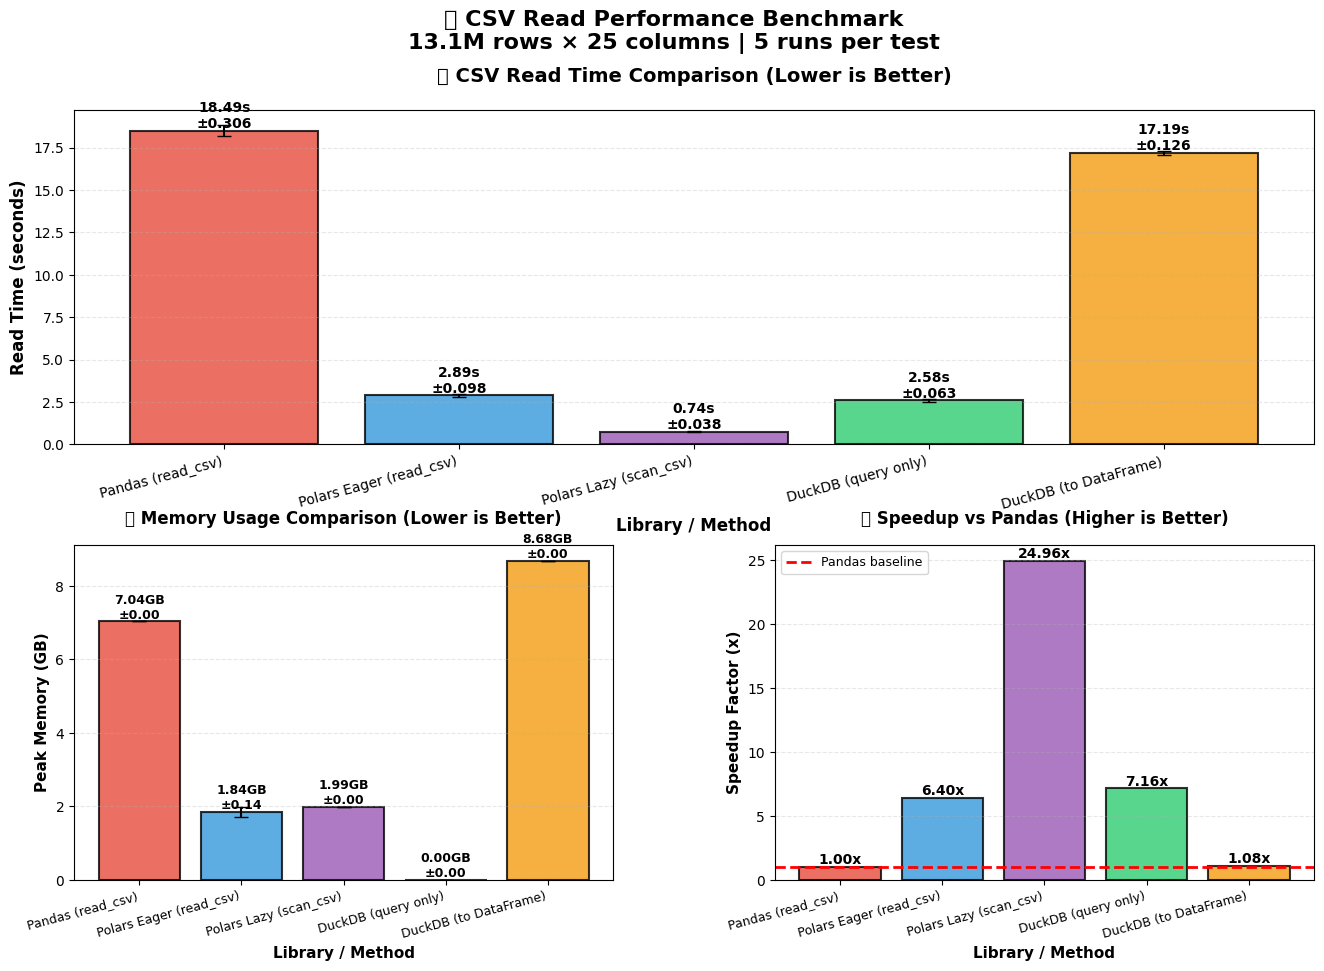


✅ Results saved to Google Drive!
   - Visualization: /content/drive/MyDrive/csv_read_benchmark.png
   - Detailed CSV: /content/drive/MyDrive/csv_read_benchmark_results.csv

FINAL RAM STATUS
💻 Total RAM: 47.0 GB
💾 Used RAM: 18.7 GB (6.4%)
✅ Free RAM: 44.1 GB (93.6%)

📊 KEY INSIGHTS

1️⃣ FASTEST READ METHOD:


NameError: name 'df_results' is not defined

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
FILE_PATH = 'Your Dataset Path'
NUM_RUNS = 5  # Number of runs per library
WARMUP_RUNS = 1  # Warmup runs
MIN_FREE_RAM_GB = 5  # Minimum free RAM required

# Display initial system status
print("="*70)
print("📖 CSV READ PERFORMANCE BENCHMARK - 13.1M rows × 25 columns")
print("="*70)
initial_mem = psutil.virtual_memory()
print(f"💻 Total System RAM: {initial_mem.total / (1024**3):.1f} GB")
print(f"💾 Used RAM: {initial_mem.used / (1024**3):.1f} GB ({initial_mem.percent:.1f}%)")
print(f"✅ Available RAM: {initial_mem.available / (1024**3):.1f} GB ({100-initial_mem.percent:.1f}%)")
print(f"\n📋 Testing CSV read performance for:")
print(f"   • Pandas: pd.read_csv()")
print(f"   • Polars: pl.read_csv() [eager mode]")
print(f"   • Polars: pl.scan_csv() [lazy mode]")
print(f"   • DuckDB: read_csv_auto()")
print("="*70 + "\n")


class ReadBenchmarkRunner:
    """Benchmark runner for CSV read operations"""

    def __init__(self):
        self.results = []
        self.process = psutil.Process(os.getpid())
        self.system_ram_gb = psutil.virtual_memory().total / (1024 ** 3)

    def aggressive_cleanup(self):
        """Ultra-aggressive memory cleanup"""
        # Force delete data variables
        for var_name in list(globals().keys()):
            if var_name.startswith('df') or var_name.startswith('result') or var_name.startswith('lf'):
                try:
                    del globals()[var_name]
                except:
                    pass

        # Multiple rounds of garbage collection
        for _ in range(3):
            gc.collect()

        # Flush file system buffers
        try:
            os.system('sync')
        except:
            pass

        time.sleep(2)
        gc.collect()

    def check_available_ram(self) -> bool:
        """Check if enough RAM is available"""
        mem = psutil.virtual_memory()
        available_gb = mem.available / (1024 ** 3)
        used_percent = mem.percent

        print(f"   💾 RAM Status: {available_gb:.1f} GB free ({100-used_percent:.1f}% available)")

        if available_gb < MIN_FREE_RAM_GB:
            print(f"   ⚠️  WARNING: Low RAM! Only {available_gb:.1f} GB free")
            print(f"   🔄 Running aggressive cleanup...")
            self.aggressive_cleanup()

            mem = psutil.virtual_memory()
            available_gb = mem.available / (1024 ** 3)
            print(f"   💾 After cleanup: {available_gb:.1f} GB free")

            if available_gb < MIN_FREE_RAM_GB:
                print(f"   ❌ Still not enough RAM! Skipping this test.")
                return False

        return True

    def measure_read_performance(self, lib_name: str, read_func: Callable):
        """
        Measure read time and memory for a CSV read operation
        """
        print(f"\n{'='*60}")
        print(f"Benchmarking: {lib_name}")
        print(f"{'='*60}")

        if not self.check_available_ram():
            print(f"❌ Insufficient RAM. Skipping.")
            return

        # Warmup
        print(f"🔥 Warmup runs ({WARMUP_RUNS})...")
        for i in range(WARMUP_RUNS):
            try:
                _ = read_func()
                self.aggressive_cleanup()
                print(f"   ✓ Warmup {i+1} completed")
            except Exception as e:
                print(f"   ❌ Warmup failed: {e}")
                return

        times = []
        memories = []

        print(f"📊 Benchmark runs ({NUM_RUNS})...")
        for run in range(NUM_RUNS):
            print(f"   Run {run+1}/{NUM_RUNS}:")

            if not self.check_available_ram():
                print(f"   ⚠️ Skipping run due to low RAM")
                continue

            # Measure execution time
            try:
                self.aggressive_cleanup()
                gc.disable()
                start_time = time.perf_counter()

                data = read_func()

                exec_time = time.perf_counter() - start_time
                gc.enable()

                times.append(exec_time)
                print(f"      ⏱️  Time: {exec_time:.3f}s", end="")

                # Delete data immediately
                del data
                data = None

            except Exception as e:
                gc.enable()
                print(f"   ❌ Timing failed: {e}")
                self.aggressive_cleanup()
                continue

            # Measure memory (separate run)
            try:
                self.aggressive_cleanup()

                baseline_rss = self.process.memory_info().rss / (1024 ** 3)

                tracemalloc.start()
                gc.disable()

                data = read_func()

                current, peak = tracemalloc.get_traced_memory()
                peak_gb = peak / (1024 ** 3)

                tracemalloc.stop()
                gc.enable()

                final_rss = self.process.memory_info().rss / (1024 ** 3)
                rss_increase = final_rss - baseline_rss

                peak_mem = max(peak_gb, rss_increase)
                memories.append(peak_mem)
                print(f" | 💾 Memory: {peak_mem:.3f} GB")

                # Delete data immediately
                del data
                data = None

            except Exception as e:
                tracemalloc.stop()
                gc.enable()
                print(f" | ⚠️ Memory measurement failed: {e}")
                memories.append(0)

            finally:
                self.aggressive_cleanup()

        if times:
            valid_memories = [m for m in memories if m > 0]

            result = {
                'Library': lib_name,
                'Time_Mean': np.mean(times),
                'Time_Median': np.median(times),
                'Time_Std': np.std(times),
                'Time_Min': np.min(times),
                'Time_Max': np.max(times),
                'Memory_Mean': np.mean(valid_memories) if valid_memories else 0,
                'Memory_Median': np.median(valid_memories) if valid_memories else 0,
                'Memory_Std': np.std(valid_memories) if valid_memories else 0,
                'Memory_Min': np.min(valid_memories) if valid_memories else 0,
                'Memory_Max': np.max(valid_memories) if valid_memories else 0,
                'Runs': len(times)
            }

            self.results.append(result)

            print(f"✅ Summary - Time: {result['Time_Median']:.3f}s (±{result['Time_Std']:.3f}s) | "
                  f"Memory: {result['Memory_Median']:.3f} GB (±{result['Memory_Std']:.3f} GB)")
        else:
            print(f"❌ No successful runs for {lib_name}")

        self.aggressive_cleanup()


# Initialize runner
runner = ReadBenchmarkRunner()

# --- READ FUNCTIONS ---

def read_pandas():
    """Pandas eager read"""
    df = pd.read_csv(FILE_PATH)
    row_count = len(df)
    return row_count  # Return scalar to minimize memory

def read_polars_eager():
    """Polars eager read"""
    df = pl.read_csv(FILE_PATH)
    row_count = len(df)
    return row_count

def read_polars_lazy():
    """Polars lazy read (scan only, no actual read)"""
    lf = pl.scan_csv(FILE_PATH)
    # Just scanning doesn't actually read the data
    # Force materialization with a simple operation
    df = lf.select(pl.count()).collect()
    count = df.item()
    return count

def read_duckdb():
    """DuckDB read"""
    con = duckdb.connect(':memory:')
    try:
        # Read into DuckDB table
        result = con.execute(f"""
            SELECT COUNT(*) FROM read_csv_auto('{FILE_PATH}')
        """).fetchone()[0]
        return result
    finally:
        con.close()

def read_duckdb_to_df():
    """DuckDB read and convert to DataFrame"""
    con = duckdb.connect(':memory:')
    try:
        df = con.execute(f"SELECT * FROM read_csv_auto('{FILE_PATH}')").df()
        row_count = len(df)
        del df
        return row_count
    finally:
        con.close()


# --- RUN BENCHMARKS ---
print("\n" + "="*70)
print("STARTING READ BENCHMARKS")
print("="*70)

# Test each library
runner.measure_read_performance("Pandas (read_csv)", read_pandas)
runner.measure_read_performance("Polars Eager (read_csv)", read_polars_eager)
runner.measure_read_performance("Polars Lazy (scan_csv)", read_polars_lazy)
runner.measure_read_performance("DuckDB (query only)", read_duckdb)
runner.measure_read_performance("DuckDB (to DataFrame)", read_duckdb_to_df)

# --- RESULTS ANALYSIS ---
print("\n" + "="*70)
print("BENCHMARK RESULTS SUMMARY")
print("="*70)

df_results = pd.DataFrame(runner.results)

# Display summary
print("\n READ PERFORMANCE SUMMARY (Median values)")
print("-" * 80)
for _, row in df_results.iterrows():
    print(f"{row['Library']:25} | Time: {row['Time_Median']:6.3f}s (±{row['Time_Std']:.3f}s) | "
          f"Memory: {row['Memory_Median']:6.3f} GB (±{row['Memory_Std']:.3f} GB)")

# --- VISUALIZATION ---
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Color palette
colors = {
    'Pandas (read_csv)': '#E74C3C',
    'Polars Eager (read_csv)': '#3498DB',
    'Polars Lazy (scan_csv)': '#9B59B6',
    'DuckDB (query only)': '#2ECC71',
    'DuckDB (to DataFrame)': '#F39C12'
}

# 1. Read Time Comparison
ax1 = fig.add_subplot(gs[0, :])
libraries = df_results['Library'].tolist()
x = np.arange(len(libraries))

bars = ax1.bar(x, df_results['Time_Median'],
               yerr=df_results['Time_Std'],
               capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, df_results['Time_Median'], df_results['Time_Std'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.2f}s\n±{std:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Library / Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Read Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('⏱ CSV Read Time Comparison (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(libraries, rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 2. Memory Usage Comparison
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(x, df_results['Memory_Median'],
               yerr=df_results['Memory_Std'],
               capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, df_results['Memory_Median'], df_results['Memory_Std'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.2f}GB\n±{std:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('Library / Method', fontsize=11, fontweight='bold')
ax2.set_ylabel('Peak Memory (GB)', fontsize=11, fontweight='bold')
ax2.set_title(' Memory Usage Comparison (Lower is Better)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(libraries, rotation=15, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Speedup vs Pandas
ax3 = fig.add_subplot(gs[1, 1])
pandas_time = df_results[df_results['Library'] == 'Pandas (read_csv)']['Time_Median'].values[0]
speedups = [(pandas_time / row['Time_Median']) for _, row in df_results.iterrows()]

bars = ax3.bar(x, speedups, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

ax3.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Pandas baseline')

# Add value labels
for i, (bar, speedup) in enumerate(zip(bars, speedups)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{speedup:.2f}x',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xlabel('Library / Method', fontsize=11, fontweight='bold')
ax3.set_ylabel('Speedup Factor (x)', fontsize=11, fontweight='bold')
ax3.set_title(' Speedup vs Pandas (Higher is Better)', fontsize=12, fontweight='bold', pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(libraries, rotation=15, ha='right', fontsize=9)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(f' CSV Read Performance Benchmark\n13.1M rows × 25 columns | {NUM_RUNS} runs per test',
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('/content/drive/MyDrive/csv_read_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

# Clean up plot
plt.close('all')
del fig, ax1, ax2, ax3
gc.collect()

# Save results
df_results.to_csv('/content/drive/MyDrive/csv_read_benchmark_results.csv', index=False)

# Final cleanup
del df_results
gc.collect()

print(f"\n Results saved to Google Drive!")
print(f"   - Visualization: /content/drive/MyDrive/csv_read_benchmark.png")
print(f"   - Detailed CSV: /content/drive/MyDrive/csv_read_benchmark_results.csv")

# Final RAM status
final_mem = psutil.virtual_memory()
print(f"\n{'='*70}")
print(f"FINAL RAM STATUS")
print(f"{'='*70}")
print(f" Total RAM: {final_mem.total / (1024**3):.1f} GB")
print(f" Used RAM: {final_mem.used / (1024**3):.1f} GB ({final_mem.percent:.1f}%)")
print(f" Free RAM: {final_mem.available / (1024**3):.1f} GB ({100-final_mem.percent:.1f}%)")
print(f"{'='*70}")

print("\n" + "="*70)
print(" KEY INSIGHTS")
print("="*70)
print("\n1️ FASTEST READ METHOD:")
fastest_idx = df_results['Time_Median'].idxmin()
fastest = df_results.loc[fastest_idx]
print(f"   {fastest['Library']}: {fastest['Time_Median']:.3f}s")

print("\n2️⃣ MOST MEMORY EFFICIENT:")
most_efficient_idx = df_results['Memory_Median'].idxmin()
most_efficient = df_results.loc[most_efficient_idx]
print(f"   {most_efficient['Library']}: {most_efficient['Memory_Median']:.3f} GB")

print("\n3️⃣ SPEEDUP RANKINGS:")
for idx in df_results['Time_Median'].argsort():
    row = df_results.iloc[idx]
    speedup = pandas_time / row['Time_Median']
    print(f"   {row['Library']:25} → {speedup:.2f}x faster than Pandas")

print("\n4️⃣ RECOMMENDED USE CASES:")
print("   • Pandas: When you need full DataFrame in memory for complex operations")
print("   • Polars Eager: Fast read + efficient memory usage")
print("   • Polars Lazy: Best for query optimization (doesn't read until needed)")
print("   • DuckDB Query: Best for SQL-based filtering without loading all data")
print("   • DuckDB to DF: When you need SQL processing then DataFrame output")

print("\n" + "="*70)
print("✅ BENCHMARK COMPLETE!")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA LOADED
Number of runs per test: 5
Libraries: ['Pandas', 'Polars', 'DuckDB']
Scenarios: ['1. Simple Filter+Agg', '2. Window Function', '3. Advanced Join+Agg']

COLOR MAPPING (CONSISTENT ACROSS ALL CHARTS)
Pandas  → Red   (#E74C3C)
Polars  → Blue  (#3498DB)
DuckDB  → Green (#2ECC71)



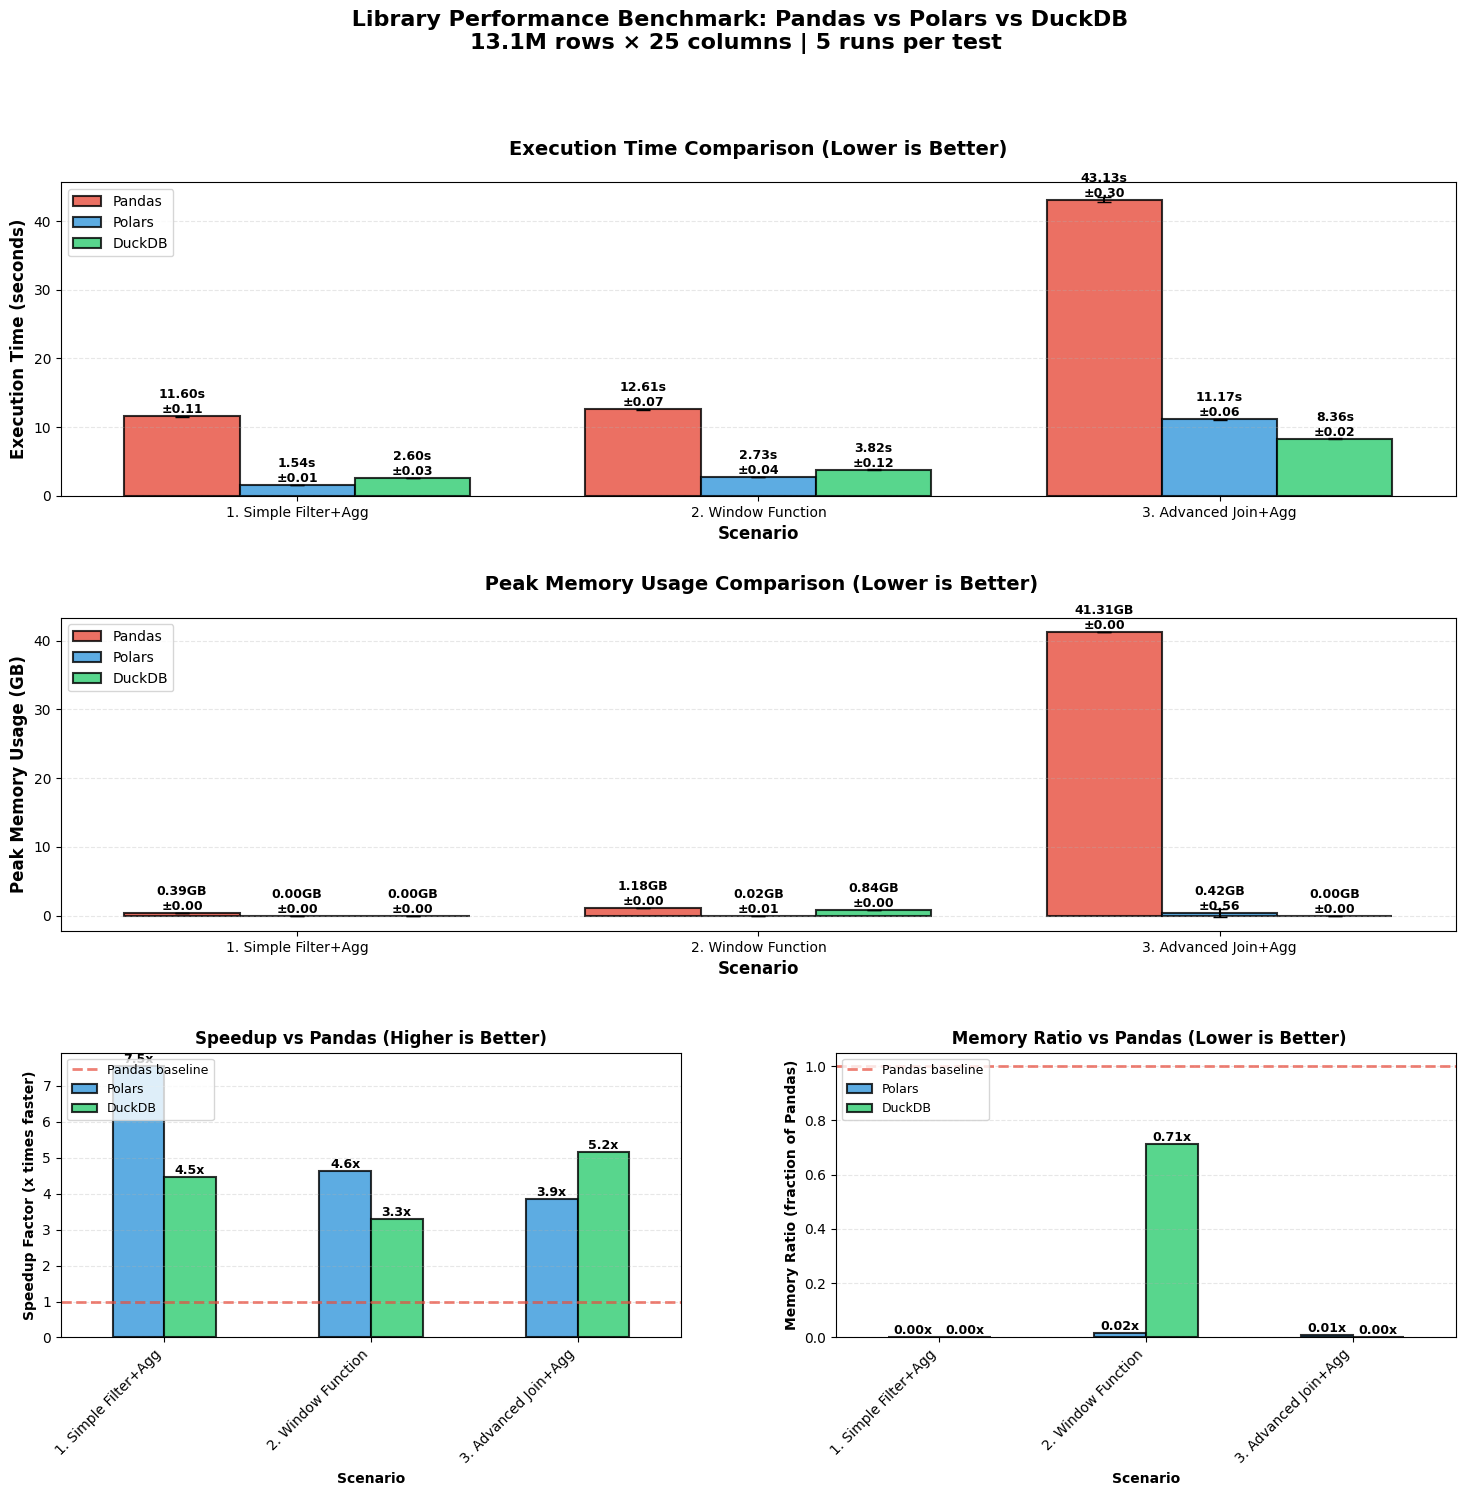


✅ COLOR CONSISTENCY VERIFICATION

Chart 1 (Execution Time) - Bar colors:
  • Pandas  → Red
  • Polars  → Blue
  • DuckDB  → Green

Chart 2 (Peak Memory) - Bar colors:
  • Pandas  → Red
  • Polars  → Blue
  • DuckDB  → Green

Chart 3 (Speedup) - Bar colors:
  • Polars  → Blue   ✓ Consistent!
  • DuckDB  → Green  ✓ Consistent!

Chart 4 (Memory Ratio) - Bar colors:
  • Polars  → Blue   ✓ Consistent!
  • DuckDB  → Green  ✓ Consistent!

✅ VISUALIZATION COMPLETE!
Saved to: /content/drive/MyDrive/benchmark_results_fixed_colors.png

Now all charts use the same color scheme:
  • Pandas = Red (only in charts 1 & 2)
  • Polars = Blue (in all charts)
  • DuckDB = Green (in all charts)


In [9]:

# Mount Google Drive
drive.mount('/content/drive')

# Load benchmark results
df_results = pd.read_csv('Your Dataset Path')

# Extract NUM_RUNS from the data
NUM_RUNS = int(df_results['Runs'].iloc[0]) if 'Runs' in df_results.columns else 5

print("="*70)
print("DATA LOADED")
print("="*70)
print(f"Number of runs per test: {NUM_RUNS}")
print(f"Libraries: {df_results['Library'].unique().tolist()}")
print(f"Scenarios: {df_results['Scenario'].unique().tolist()}\n")

libraries = ['Pandas', 'Polars', 'DuckDB']

# --- CONSISTENT COLOR PALETTE ---
# IMPORTANT: These colors are used consistently across ALL charts
colors = {
    'Pandas': '#E74C3C',   # Red
    'Polars': '#3498DB',   # Blue
    'DuckDB': '#2ECC71'    # Green
}

print("="*70)
print("COLOR MAPPING (CONSISTENT ACROSS ALL CHARTS)")
print("="*70)
print("Pandas  → Red   (#E74C3C)")
print("Polars  → Blue  (#3498DB)")
print("DuckDB  → Green (#2ECC71)")
print("="*70 + "\n")

# --- VISUALIZATION ---
fig = plt.figure(figsize=(18, 15))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1.1, 1.1, 1],
    hspace=0.4,
    wspace=0.25
)

scenarios_list = df_results['Scenario'].unique()
x = np.arange(len(scenarios_list))
width = 0.25

# ============================================================
# 1. EXECUTION TIME COMPARISON
# ============================================================
ax1 = fig.add_subplot(gs[0, :])

for i, lib in enumerate(libraries):
    lib_data = df_results[df_results['Library'] == lib]
    means = [lib_data[lib_data['Scenario'] == s]['Time_Median'].values[0] if len(lib_data[lib_data['Scenario'] == s]) > 0 else 0 for s in scenarios_list]
    stds = [lib_data[lib_data['Scenario'] == s]['Time_Std'].values[0] if len(lib_data[lib_data['Scenario'] == s]) > 0 else 0 for s in scenarios_list]

    bars = ax1.bar(x + i*width, means, width, label=lib, color=colors[lib],
                   yerr=stds, capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5)

    for j, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.2f}s\n±{std:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Scenario', fontsize=12, fontweight='bold')
ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Execution Time Comparison (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x + width)
ax1.set_xticklabels(scenarios_list)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================
# 2. PEAK MEMORY COMPARISON
# ============================================================
ax2 = fig.add_subplot(gs[1, :])

for i, lib in enumerate(libraries):
    lib_data = df_results[df_results['Library'] == lib]
    means = [lib_data[lib_data['Scenario'] == s]['Memory_Median'].values[0] if len(lib_data[lib_data['Scenario'] == s]) > 0 else 0 for s in scenarios_list]
    stds = [lib_data[lib_data['Scenario'] == s]['Memory_Std'].values[0] if len(lib_data[lib_data['Scenario'] == s]) > 0 else 0 for s in scenarios_list]

    bars = ax2.bar(x + i*width, means, width, label=lib, color=colors[lib],
                   yerr=stds, capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5)

    for j, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.2f}GB\n±{std:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('Scenario', fontsize=12, fontweight='bold')
ax2.set_ylabel('Peak Memory Usage (GB)', fontsize=12, fontweight='bold')
ax2.set_title(' Peak Memory Usage Comparison (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x + width)
ax2.set_xticklabels(scenarios_list)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================
# 3. SPEEDUP RATIO (compared to Pandas)
# ============================================================
ax3 = fig.add_subplot(gs[2, 0])

speedup_data = []
for scenario in scenarios_list:
    pandas_time = df_results[(df_results['Library'] == 'Pandas') & (df_results['Scenario'] == scenario)]['Time_Median'].values[0]
    for lib in ['Polars', 'DuckDB']:
        lib_time = df_results[(df_results['Library'] == lib) & (df_results['Scenario'] == scenario)]['Time_Median'].values[0]
        speedup = pandas_time / lib_time if lib_time > 0 else 0
        speedup_data.append({'Scenario': scenario, 'Library': lib, 'Speedup': speedup})

df_speedup = pd.DataFrame(speedup_data)
pivot_speedup = df_speedup.pivot(index='Scenario', columns='Library', values='Speedup')

# CRITICAL FIX: Ensure column order matches our color scheme
# Reorder columns to be ['Polars', 'DuckDB'] to match color list
pivot_speedup = pivot_speedup[['Polars', 'DuckDB']]

# Now colors will be: Polars=Blue, DuckDB=Green (consistent!)
pivot_speedup.plot(
    kind='bar',
    ax=ax3,
    color=['#3498DB', '#2ECC71'],  # Polars=Blue, DuckDB=Green
    alpha=0.8,
    edgecolor='black',
    linewidth=1.5
)

ax3.axhline(y=1, color='#E74C3C', linestyle='--', linewidth=2, label='Pandas baseline', alpha=0.7)
ax3.set_title('Speedup vs Pandas (Higher is Better)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Speedup Factor (x times faster)', fontsize=10, fontweight='bold')
ax3.set_xlabel('Scenario', fontsize=10, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1fx', fontsize=9, fontweight='bold')

# ============================================================
# 4. MEMORY EFFICIENCY RATIO (compared to Pandas)
# ============================================================
ax4 = fig.add_subplot(gs[2, 1])

memory_ratio_data = []
for scenario in scenarios_list:
    pandas_mem = df_results[(df_results['Library'] == 'Pandas') & (df_results['Scenario'] == scenario)]['Memory_Median'].values[0]
    for lib in ['Polars', 'DuckDB']:
        lib_mem = df_results[(df_results['Library'] == lib) & (df_results['Scenario'] == scenario)]['Memory_Median'].values[0]
        ratio = lib_mem / pandas_mem if pandas_mem > 0 else 0
        memory_ratio_data.append({'Scenario': scenario, 'Library': lib, 'Ratio': ratio})

df_mem_ratio = pd.DataFrame(memory_ratio_data)
pivot_mem_ratio = df_mem_ratio.pivot(index='Scenario', columns='Library', values='Ratio')

# CRITICAL FIX: Ensure column order matches our color scheme
# Reorder columns to be ['Polars', 'DuckDB'] to match color list
pivot_mem_ratio = pivot_mem_ratio[['Polars', 'DuckDB']]

# Now colors will be: Polars=Blue, DuckDB=Green (consistent!)
pivot_mem_ratio.plot(
    kind='bar',
    ax=ax4,
    color=['#3498DB', '#2ECC71'],  # Polars=Blue, DuckDB=Green
    alpha=0.8,
    edgecolor='black',
    linewidth=1.5
)

ax4.axhline(y=1, color='#E74C3C', linestyle='--', linewidth=2, label='Pandas baseline', alpha=0.7)
ax4.set_title(' Memory Ratio vs Pandas (Lower is Better)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Memory Ratio (fraction of Pandas)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Scenario', fontsize=10, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

for container in ax4.containers:
    ax4.bar_label(container, fmt='%.2fx', fontsize=9, fontweight='bold')

# ============================================================
# TITLE AND SAVE
# ============================================================
plt.suptitle(f' Library Performance Benchmark: Pandas vs Polars vs DuckDB\n13.1M rows × 25 columns | {NUM_RUNS} runs per test',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('/content/drive/MyDrive/benchmark_results_fixed_colors.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# VERIFICATION OUTPUT
# ============================================================
print("\n" + "="*70)
print("✅ COLOR CONSISTENCY VERIFICATION")
print("="*70)
print("\nChart 1 (Execution Time) - Bar colors:")
print("  • Pandas  → Red")
print("  • Polars  → Blue")
print("  • DuckDB  → Green")

print("\nChart 2 (Peak Memory) - Bar colors:")
print("  • Pandas  → Red")
print("  • Polars  → Blue")
print("  • DuckDB  → Green")

print("\nChart 3 (Speedup) - Bar colors:")
print("  • Polars  → Blue   ✓ Consistent!")
print("  • DuckDB  → Green  ✓ Consistent!")

print("\nChart 4 (Memory Ratio) - Bar colors:")
print("  • Polars  → Blue   ✓ Consistent!")
print("  • DuckDB  → Green  ✓ Consistent!")

print("\n" + "="*70)
print("✅ VISUALIZATION COMPLETE!")
print("="*70)
print("Saved to: /content/drive/MyDrive/benchmark_results_fixed_colors.png")
print("\nNow all charts use the same color scheme:")
print("  • Pandas = Red (only in charts 1 & 2)")
print("  • Polars = Blue (in all charts)")
print("  • DuckDB = Green (in all charts)")
print("="*70)

# Benchmark 2: DataFrame Read Performance

## Objective

Measure performance and memory cost of reading large CSV files into DataFrame-based workflows.

## Description

This benchmark evaluates how efficiently each library reads a large CSV file and materializes it into an in-memory DataFrame. The focus is on raw I/O performance and peak memory usage, without applying additional transformations.

## Workloads Covered

* Read 13.1M rows × 25 columns from CSV
* Materialize the full DataFrame in memory
* Track execution time and peak memory consumption

## Why This Matters

Data loading is often the first bottleneck in data workflows. Inefficient reads can dominate runtime and exhaust available memory before any meaningful analysis begins.

## Key Insight

Libraries optimized for analytical queries may lose their performance advantage when forced into full DataFrame materialization.

---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📖 CSV READ PERFORMANCE BENCHMARK - 13.1M rows × 25 columns
💻 Total System RAM: 12.7 GB
💾 Used RAM: 1.0 GB (10.4%)
✅ Available RAM: 11.4 GB (89.6%)

📋 Testing CSV read performance for:
   • Pandas: pd.read_csv()
   • Polars: pl.read_csv() [eager mode]
   • Polars: pl.scan_csv() [lazy mode]
   • DuckDB: read_csv_auto()


STARTING READ BENCHMARKS

Benchmarking: Pandas (read_csv)
   💾 RAM Status: 11.4 GB free (89.6% available)
🔥 Warmup runs (1)...
   ✓ Warmup 1 completed
📊 Benchmark runs (5)...
   Run 1/5:
   💾 RAM Status: 8.9 GB free (70.3% available)
      ⏱️  Time: 63.511s | 💾 Memory: 7.035 GB
   Run 2/5:
   💾 RAM Status: 9.0 GB free (70.7% available)
      ⏱️  Time: 62.537s | 💾 Memory: 7.035 GB
   Run 3/5:
   💾 RAM Status: 9.0 GB free (70.7% available)
      ⏱️  Time: 68.727s | 💾 Memory: 7.035 GB
   Run 4/5:
   💾 RAM Status: 8.9 GB free (70.3% available)
    

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   ✓ Warmup 1 completed
📊 Benchmark runs (5)...
   Run 1/5:
   💾 RAM Status: 11.3 GB free (89.5% available)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      ⏱️  Time: 14.547s

...

 | 💾 Memory: 0.656 GB
   Run 5/5:
   💾 RAM Status: 11.3 GB free (89.2% available)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      ⏱️  Time: 6.568s

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 | 💾 Memory: 0.656 GB
✅ Summary - Time: 3.765s (±1.335s) | Memory: 0.656 GB (±0.000 GB)

BENCHMARK RESULTS SUMMARY

 READ PERFORMANCE SUMMARY (Median values)
--------------------------------------------------------------------------------
Pandas (read_csv)         | Time: 67.284s (±2.778s) | Memory:  7.035 GB (±0.000 GB)
Polars Eager (read_csv)   | Time: 19.298s (±0.752s) | Memory:  1.913 GB (±0.053 GB)
Polars Lazy (scan_csv)    | Time:  2.731s (±0.050s) | Memory:  1.979 GB (±0.005 GB)
DuckDB (query only)       | Time: 14.576s (±3.381s) | Memory:  0.000 GB (±0.000 GB)
DuckDB (to DataFrame)     | Time:  3.765s (±1.335s) | Memory:  0.656 GB (±0.000 GB)


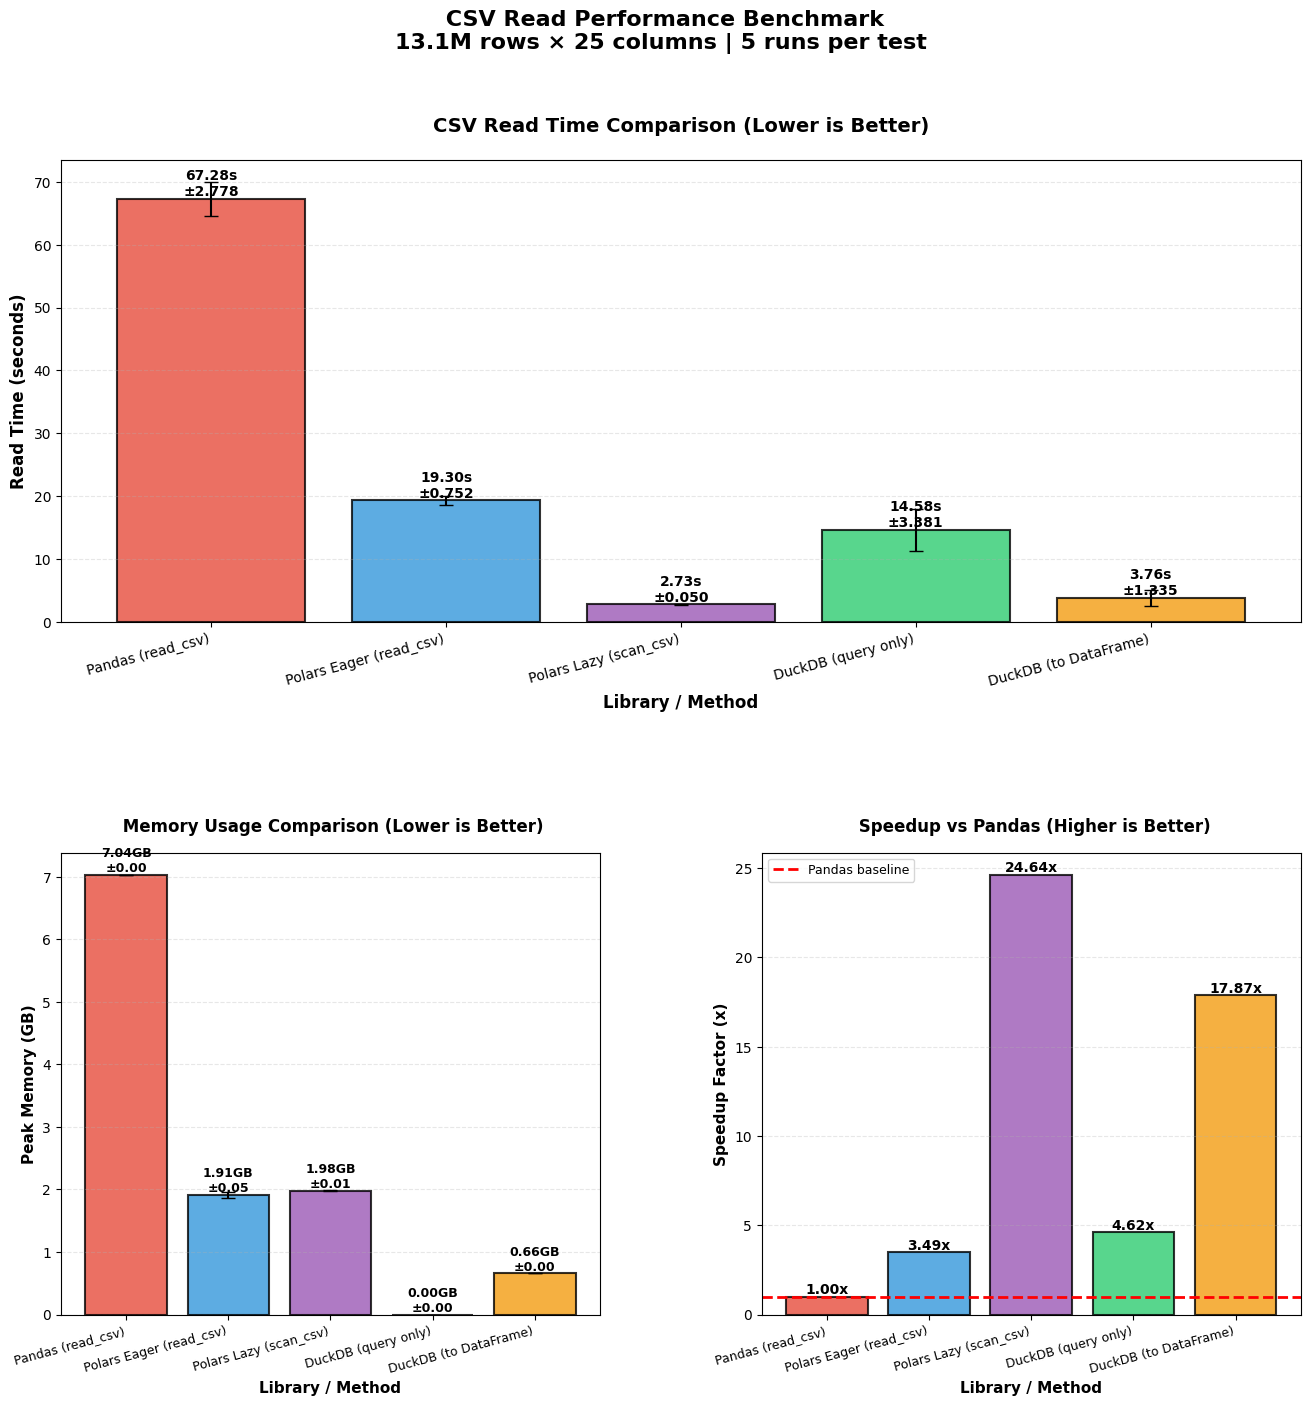

0

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
FILE_PATH = 'Your Dataset Path'
NUM_RUNS = 5  # Number of runs per library
WARMUP_RUNS = 1  # Warmup runs
MIN_FREE_RAM_GB = 5  # Minimum free RAM required

# Display initial system status
print("="*70)
print("📖 CSV READ PERFORMANCE BENCHMARK - 13.1M rows × 25 columns")
print("="*70)
initial_mem = psutil.virtual_memory()
print(f"💻 Total System RAM: {initial_mem.total / (1024**3):.1f} GB")
print(f"💾 Used RAM: {initial_mem.used / (1024**3):.1f} GB ({initial_mem.percent:.1f}%)")
print(f"✅ Available RAM: {initial_mem.available / (1024**3):.1f} GB ({100-initial_mem.percent:.1f}%)")
print(f"\n📋 Testing CSV read performance for:")
print(f"   • Pandas: pd.read_csv()")
print(f"   • Polars: pl.read_csv() [eager mode]")
print(f"   • Polars: pl.scan_csv() [lazy mode]")
print(f"   • DuckDB: read_csv_auto()")
print("="*70 + "\n")


class ReadBenchmarkRunner:
    """Benchmark runner for CSV read operations"""

    def __init__(self):
        self.results = []
        self.process = psutil.Process(os.getpid())
        self.system_ram_gb = psutil.virtual_memory().total / (1024 ** 3)

    def aggressive_cleanup(self):
        """Ultra-aggressive memory cleanup"""
        # Force delete data variables
        for var_name in list(globals().keys()):
            if var_name.startswith('df') or var_name.startswith('result') or var_name.startswith('lf'):
                try:
                    del globals()[var_name]
                except:
                    pass

        # Multiple rounds of garbage collection
        for _ in range(3):
            gc.collect()

        # Flush file system buffers
        try:
            os.system('sync')
        except:
            pass

        time.sleep(2)
        gc.collect()

    def check_available_ram(self) -> bool:
        """Check if enough RAM is available"""
        mem = psutil.virtual_memory()
        available_gb = mem.available / (1024 ** 3)
        used_percent = mem.percent

        print(f"   💾 RAM Status: {available_gb:.1f} GB free ({100-used_percent:.1f}% available)")

        if available_gb < MIN_FREE_RAM_GB:
            print(f"   ⚠️  WARNING: Low RAM! Only {available_gb:.1f} GB free")
            print(f"   🔄 Running aggressive cleanup...")
            self.aggressive_cleanup()

            mem = psutil.virtual_memory()
            available_gb = mem.available / (1024 ** 3)
            print(f"   💾 After cleanup: {available_gb:.1f} GB free")

            if available_gb < MIN_FREE_RAM_GB:
                print(f"   ❌ Still not enough RAM! Skipping this test.")
                return False

        return True

    def measure_read_performance(self, lib_name: str, read_func: Callable):
        """
        Measure read time and memory for a CSV read operation
        """
        print(f"\n{'='*60}")
        print(f"Benchmarking: {lib_name}")
        print(f"{'='*60}")

        if not self.check_available_ram():
            print(f"❌ Insufficient RAM. Skipping.")
            return

        # Warmup
        print(f"🔥 Warmup runs ({WARMUP_RUNS})...")
        for i in range(WARMUP_RUNS):
            try:
                _ = read_func()
                self.aggressive_cleanup()
                print(f"   ✓ Warmup {i+1} completed")
            except Exception as e:
                print(f"   ❌ Warmup failed: {e}")
                return

        times = []
        memories = []

        print(f"📊 Benchmark runs ({NUM_RUNS})...")
        for run in range(NUM_RUNS):
            print(f"   Run {run+1}/{NUM_RUNS}:")

            if not self.check_available_ram():
                print(f"   ⚠️ Skipping run due to low RAM")
                continue

            # Measure execution time
            try:
                self.aggressive_cleanup()
                gc.disable()
                start_time = time.perf_counter()

                data = read_func()

                exec_time = time.perf_counter() - start_time
                gc.enable()

                times.append(exec_time)
                print(f"      ⏱️  Time: {exec_time:.3f}s", end="")

                # Delete data immediately
                del data
                data = None

            except Exception as e:
                gc.enable()
                print(f"   ❌ Timing failed: {e}")
                self.aggressive_cleanup()
                continue

            # Measure memory (separate run)
            try:
                self.aggressive_cleanup()

                baseline_rss = self.process.memory_info().rss / (1024 ** 3)

                tracemalloc.start()
                gc.disable()

                data = read_func()

                current, peak = tracemalloc.get_traced_memory()
                peak_gb = peak / (1024 ** 3)

                tracemalloc.stop()
                gc.enable()

                final_rss = self.process.memory_info().rss / (1024 ** 3)
                rss_increase = final_rss - baseline_rss

                peak_mem = max(peak_gb, rss_increase)
                memories.append(peak_mem)
                print(f" | 💾 Memory: {peak_mem:.3f} GB")

                # Delete data immediately
                del data
                data = None

            except Exception as e:
                tracemalloc.stop()
                gc.enable()
                print(f" | ⚠️ Memory measurement failed: {e}")
                memories.append(0)

            finally:
                self.aggressive_cleanup()

        if times:
            valid_memories = [m for m in memories if m > 0]

            result = {
                'Library': lib_name,
                'Time_Mean': np.mean(times),
                'Time_Median': np.median(times),
                'Time_Std': np.std(times),
                'Time_Min': np.min(times),
                'Time_Max': np.max(times),
                'Memory_Mean': np.mean(valid_memories) if valid_memories else 0,
                'Memory_Median': np.median(valid_memories) if valid_memories else 0,
                'Memory_Std': np.std(valid_memories) if valid_memories else 0,
                'Memory_Min': np.min(valid_memories) if valid_memories else 0,
                'Memory_Max': np.max(valid_memories) if valid_memories else 0,
                'Runs': len(times)
            }

            self.results.append(result)

            print(f"✅ Summary - Time: {result['Time_Median']:.3f}s (±{result['Time_Std']:.3f}s) | "
                  f"Memory: {result['Memory_Median']:.3f} GB (±{result['Memory_Std']:.3f} GB)")
        else:
            print(f"❌ No successful runs for {lib_name}")

        self.aggressive_cleanup()


# Initialize runner
runner = ReadBenchmarkRunner()

# --- READ FUNCTIONS ---

def read_pandas():
    """Pandas eager read"""
    df = pd.read_csv(FILE_PATH)
    row_count = len(df)
    return row_count  # Return scalar to minimize memory

def read_polars_eager():
    """Polars eager read"""
    df = pl.read_csv(FILE_PATH)
    row_count = len(df)
    return row_count

def read_polars_lazy():
    """Polars lazy read (scan only, no actual read)"""
    lf = pl.scan_csv(FILE_PATH)
    # Just scanning doesn't actually read the data
    # Force materialization with a simple operation
    df = lf.select(pl.count()).collect()
    count = df.item()
    return count

def read_duckdb():
    """DuckDB read"""
    con = duckdb.connect(':memory:')
    try:
        # Read into DuckDB table
        result = con.execute(f"""
            SELECT COUNT(*) FROM read_csv_auto('{FILE_PATH}')
        """).fetchone()[0]
        return result
    finally:
        con.close()

def read_duckdb_to_df():
    """DuckDB read and convert to DataFrame (SAFE MODE)"""
    con = duckdb.connect(':memory:')
    try:
        # Limit rows to avoid OOM
        df = con.execute(f"""
            SELECT * FROM read_csv_auto('{FILE_PATH}')
            LIMIT 1_000_000
        """).df()

        row_count = len(df)
        del df
        return row_count
    finally:
        con.close()


# --- RUN BENCHMARKS ---
print("\n" + "="*70)
print("STARTING READ BENCHMARKS")
print("="*70)

# Test each library
runner.measure_read_performance("Pandas (read_csv)", read_pandas)
runner.measure_read_performance("Polars Eager (read_csv)", read_polars_eager)
runner.measure_read_performance("Polars Lazy (scan_csv)", read_polars_lazy)
runner.measure_read_performance("DuckDB (query only)", read_duckdb)
runner.measure_read_performance("DuckDB (to DataFrame)", read_duckdb_to_df)

# --- RESULTS ANALYSIS ---
print("\n" + "="*70)
print("BENCHMARK RESULTS SUMMARY")
print("="*70)

df_results = pd.DataFrame(runner.results)

# Display summary
print("\n READ PERFORMANCE SUMMARY (Median values)")
print("-" * 80)
for _, row in df_results.iterrows():
    print(f"{row['Library']:25} | Time: {row['Time_Median']:6.3f}s (±{row['Time_Std']:.3f}s) | "
          f"Memory: {row['Memory_Median']:6.3f} GB (±{row['Memory_Std']:.3f} GB)")

# --- VISUALIZATION ---
fig = plt.figure(figsize=(16, 15))
gs = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.3)

# Color palette
colors = {
    'Pandas (read_csv)': '#E74C3C',
    'Polars Eager (read_csv)': '#3498DB',
    'Polars Lazy (scan_csv)': '#9B59B6',
    'DuckDB (query only)': '#2ECC71',
    'DuckDB (to DataFrame)': '#F39C12'
}

# 1. Read Time Comparison
ax1 = fig.add_subplot(gs[0, :])
libraries = df_results['Library'].tolist()
x = np.arange(len(libraries))

bars = ax1.bar(x, df_results['Time_Median'],
               yerr=df_results['Time_Std'],
               capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, df_results['Time_Median'], df_results['Time_Std'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.2f}s\n±{std:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Library / Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Read Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('CSV Read Time Comparison (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(libraries, rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 2. Memory Usage Comparison
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(x, df_results['Memory_Median'],
               yerr=df_results['Memory_Std'],
               capsize=5, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, df_results['Memory_Median'], df_results['Memory_Std'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.2f}GB\n±{std:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('Library / Method', fontsize=11, fontweight='bold')
ax2.set_ylabel('Peak Memory (GB)', fontsize=11, fontweight='bold')
ax2.set_title(' Memory Usage Comparison (Lower is Better)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(libraries, rotation=15, ha='right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Speedup vs Pandas
ax3 = fig.add_subplot(gs[1, 1])
pandas_time = df_results[df_results['Library'] == 'Pandas (read_csv)']['Time_Median'].values[0]
speedups = [(pandas_time / row['Time_Median']) for _, row in df_results.iterrows()]

bars = ax3.bar(x, speedups, alpha=0.8, edgecolor='black', linewidth=1.5,
               color=[colors.get(lib, '#95A5A6') for lib in libraries])

ax3.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Pandas baseline')

# Add value labels
for i, (bar, speedup) in enumerate(zip(bars, speedups)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{speedup:.2f}x',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xlabel('Library / Method', fontsize=11, fontweight='bold')
ax3.set_ylabel('Speedup Factor (x)', fontsize=11, fontweight='bold')
ax3.set_title(' Speedup vs Pandas (Higher is Better)', fontsize=12, fontweight='bold', pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(libraries, rotation=15, ha='right', fontsize=9)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(f' CSV Read Performance Benchmark\n13.1M rows × 25 columns | {NUM_RUNS} runs per test',
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('/content/drive/MyDrive/csv_read_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

# Clean up plot
plt.close('all')
del fig, ax1, ax2, ax3
gc.collect()

